In [1]:
import pandas as pd
from utils.files import load_xlsx, save_plot
from utils.evaluation import (
    adapt_evaluation_df,
    add_usage_to_evaluation,
    group_by,
    create_plot_correct_efficient_error_ratio_by_task_type,
    create_plot_correct_by_method_and_task_type
)

# Load Dataframe

In [2]:
df = load_xlsx("output/evaluation/evaluation.xlsx")
df = adapt_evaluation_df(df)
df = add_usage_to_evaluation(df)
# df.to_csv("output/evaluation/evaluation_xlsx.csv", index=False)
df

,task_type,task_id,method,model,tools_correct,arguments_correct,tools_efficient,arguments_efficient,correct,efficient,error,runtime_seconds,input_tokens,output_tokens,total_tokens
0,Direkte Datenabfrage,1,deterministic,qwen3:8b,1,1,1,1,1,1,NaN,22.775164,3572,1299,4871
1,Direkte Datenabfrage,1,deterministic,qwen3:30b,1,1,1,1,1,1,NaN,11.542765,3572,1054,4626
2,Direkte Datenabfrage,1,deterministic,gpt-5.4-mini,1,1,1,1,1,1,NaN,1.724466,3128,68,3196
3,Direkte Datenabfrage,1,plan-based,qwen3:8b,1,1,1,1,1,1,NaN,15.319668,4974,940,5914
4,Direkte Datenabfrage,1,plan-based,qwen3:30b,1,1,1,1,1,1,NaN,11.839647,4974,994,5968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,Mehrquellenverarbeitung,90,plan-based,qwen3:30b,0,0,0,0,0,0,timeout,NaN,<NA>,<NA>,<NA>
806,Mehrquellenverarbeitung,90,plan-based,gpt-5.4-mini,1,1,0,0,1,0,NaN,2.355729,4382,166,4548
807,Mehrquellenverarbeitung,90,iterative,qwen3:8b,0,0,0,0,0,0,timeout,NaN,<NA>,<NA>,<NA>
808,Mehrquellenverarbeitung,90,iterative,qwen3:30b,0,0,0,0,0,0,timeout,NaN,<NA>,<NA>,<NA>


# Tables

In [3]:
group_by(df, ["method"])

,tools_correct,arguments_correct,tools_efficient,arguments_efficient,correct,efficient,runtime_seconds,total_tokens,error_ratio
method,,,,,,,,,
deterministic,0.75,0.72,0.68,0.65,0.72,0.65,7.67,4019.0,0.15
iterative,0.45,0.44,0.39,0.38,0.44,0.38,13.16,8273.0,0.31
plan-based,0.60,0.59,0.50,0.49,0.59,0.49,8.84,5331.0,0.29


In [4]:
group_by(df, ["task_type"])

,tools_correct,arguments_correct,tools_efficient,arguments_efficient,correct,efficient,runtime_seconds,total_tokens,error_ratio
task_type,,,,,,,,,
Direkte Datenabfrage,0.76,0.75,0.72,0.72,0.75,0.72,8.43,6102.0,0.11
Einzelquellenverarbeitung,0.57,0.53,0.47,0.44,0.53,0.44,11.15,5718.0,0.24
Mehrquellenverarbeitung,0.47,0.46,0.37,0.36,0.46,0.36,9.82,5213.0,0.40


In [5]:
group_by(df, ["model"])

,tools_correct,arguments_correct,tools_efficient,arguments_efficient,correct,efficient,runtime_seconds,total_tokens,error_ratio
model,,,,,,,,,
gpt-5.4-mini,0.75,0.73,0.58,0.57,0.73,0.57,2.14,4351.0,0.00
qwen3:30b,0.47,0.46,0.46,0.44,0.46,0.44,11.56,6250.0,0.50
qwen3:8b,0.58,0.56,0.53,0.51,0.56,0.51,18.63,7252.0,0.25


In [3]:
group_by(df, ["model", "method"], subcriterions=False)

correct  efficient  runtime_seconds  total_tokens  \
model        method                                                             
gpt-5.4-mini deterministic     0.83       0.70             1.82        3204.0   
             iterative         0.56       0.42             2.51        5344.0   
             plan-based        0.79       0.58             2.08        4503.0   
qwen3:30b    deterministic     0.67       0.64            10.32        4656.0   
             iterative         0.40       0.39            13.51        9216.0   
             plan-based        0.30       0.29            12.04        6261.0   
qwen3:8b     deterministic     0.66       0.61            12.52        4432.0   
             iterative         0.36       0.32            29.19       12149.0   
             plan-based        0.67       0.60            16.00        6001.0   

                            error_ratio  
model        method                      
gpt-5.4-mini deterministic         0.00  
             iterative             0.00  
             plan-based            0.00  
qwen3:30b    deterministic         0.23  
             iterative             0.59  
             plan-based            0.68  
qwen3:8b     deterministic         0.21  
             iterative             0.34  
             plan-based            0.20

In [4]:
group_by(df, ["model", "task_type"], subcriterions=False)

correct  efficient  runtime_seconds  \
model        task_type                                                        
gpt-5.4-mini Direkte Datenabfrage          0.78       0.71             1.99   
             Einzelquellenverarbeitung     0.64       0.49             2.18   
             Mehrquellenverarbeitung       0.76       0.50             2.24   
qwen3:30b    Direkte Datenabfrage          0.73       0.71            10.78   
             Einzelquellenverarbeitung     0.40       0.39            12.27   
             Mehrquellenverarbeitung       0.23       0.22            12.62   
qwen3:8b     Direkte Datenabfrage          0.74       0.73            13.59   
             Einzelquellenverarbeitung     0.53       0.43            21.80   
             Mehrquellenverarbeitung       0.40       0.37            22.27   

                                        total_tokens  error_ratio  
model        task_type                                             
gpt-5.4-mini Direkte Datenabfrage             4433.0         0.00  
             Einzelquellenverarbeitung        4351.0         0.00  
             Mehrquellenverarbeitung          4267.0         0.00  
qwen3:30b    Direkte Datenabfrage             6851.0         0.23  
             Einzelquellenverarbeitung        5737.0         0.50  
             Mehrquellenverarbeitung          5378.0         0.77  
qwen3:8b     Direkte Datenabfrage             7319.0         0.10  
             Einzelquellenverarbeitung        7463.0         0.21  
             Mehrquellenverarbeitung          6845.0         0.44

In [5]:
group_by(df, ["method", "task_type"], subcriterions=False)

correct  efficient  runtime_seconds  \
method        task_type                                                        
deterministic Direkte Datenabfrage          0.79       0.77             6.11   
              Einzelquellenverarbeitung     0.64       0.54             8.34   
              Mehrquellenverarbeitung       0.72       0.64             8.90   
iterative     Direkte Datenabfrage          0.74       0.70            12.33   
              Einzelquellenverarbeitung     0.36       0.30            14.96   
              Mehrquellenverarbeitung       0.21       0.13            12.06   
plan-based    Direkte Datenabfrage          0.72       0.69             6.85   
              Einzelquellenverarbeitung     0.58       0.47            10.74   
              Mehrquellenverarbeitung       0.46       0.31             9.19   

                                         total_tokens  error_ratio  
method        task_type                                             
deterministic Direkte Datenabfrage             3827.0         0.04  
              Einzelquellenverarbeitung        4123.0         0.16  
              Mehrquellenverarbeitung          4145.0         0.24  
iterative     Direkte Datenabfrage             9298.0         0.10  
              Einzelquellenverarbeitung        7942.0         0.30  
              Mehrquellenverarbeitung          6792.0         0.53  
plan-based    Direkte Datenabfrage             5236.0         0.19  
              Einzelquellenverarbeitung        5432.0         0.26  
              Mehrquellenverarbeitung          5336.0         0.43

In [ ]:
plot = df.groupby(["task_type"], as_index=True).agg(
    correct=("correct", "mean"),
    efficient=("efficient", "mean"),
)

plot

,correct,efficient
task_type,,
Direkte Datenabfrage,0.751852,0.718519
Einzelquellenverarbeitung,0.525926,0.437037
Mehrquellenverarbeitung,0.462963,0.362963


# Plots

plot saved: output/plots/correct_efficient_error_ratio_by_task_type.png


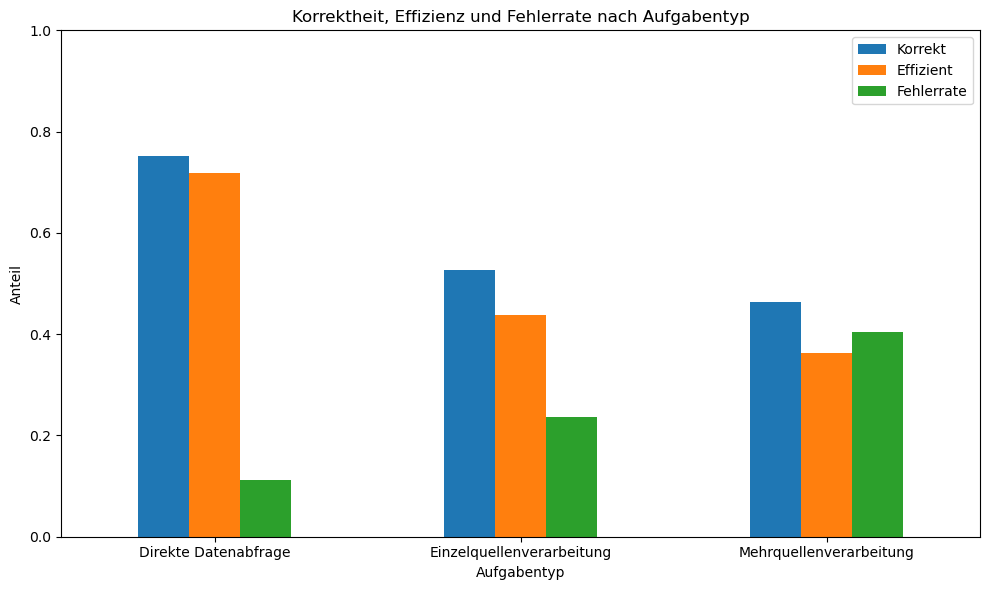

In [4]:
plot = create_plot_correct_efficient_error_ratio_by_task_type(df)
path = save_plot(plot, "correct_efficient_error_ratio_by_task_type")
print(f"plot saved: {path}")

plot saved: output/plots/correct_by_method_and_task_type.png


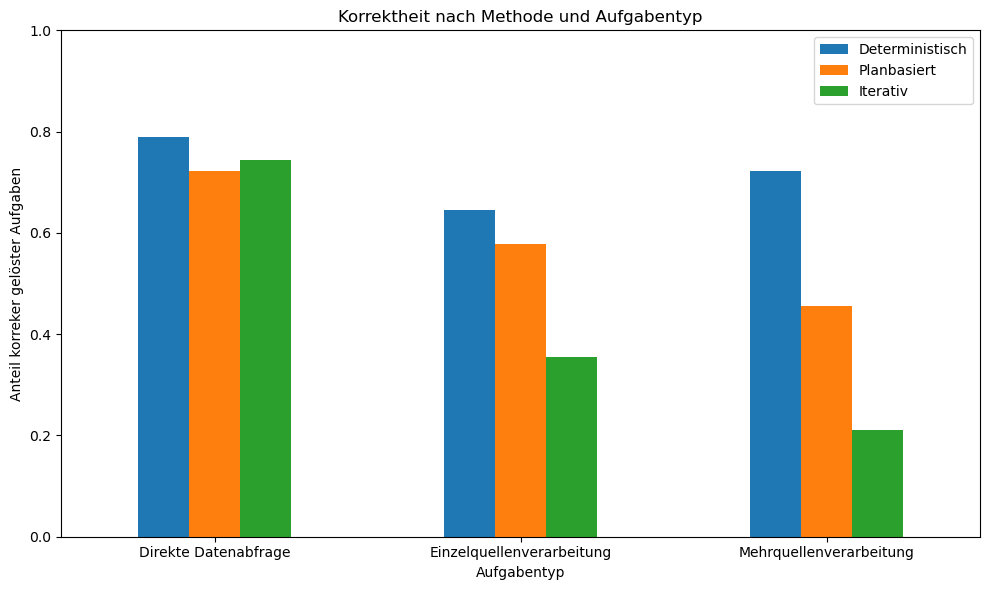

In [5]:
plot = create_plot_correct_by_method_and_task_type(df)
path = save_plot(plot, "correct_by_method_and_task_type")
print(f"plot saved: {path}")